# Grouping Feature Ablation: Primary-Only ranking

This notebook reads `experiment_metric_summary/grouping_feature_ablation_primary_only_sorted.csv` and compares fixed grouping, feature-set ablations, and soft-router runs.

Sorting rule: lower `primary_rank` is better.

Comfort severity uses `primary_comfort_degree_hours_per_building_day`, the mean across every building and test day (`°C·h/(building·day)`); no building is randomly sampled. The original `primary_comfort_exceedance_pct` and portfolio total remain beside it for reference.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 140)

repo_dir = Path.cwd()
if repo_dir.name == "notebooks":
    repo_dir = repo_dir.parent

csv_path = repo_dir / "experiment_metric_summary" / "grouping_feature_ablation_primary_only_sorted.csv"
df = pd.read_csv(csv_path)

for col in ["primary_rank", "overall_rank"]:
    if col in df.columns:
        df[col] = df[col].astype(int)

display(Markdown(f"Loaded `{csv_path}` with **{len(df)}** rows."))
display(Markdown("Columns: `" + "`, `".join(df.columns) + "`"))

Loaded `C:\Users\16199\Desktop\RL\annex96_common_exercise_1\experiment_metric_summary\grouping_feature_ablation_primary_only_sorted.csv` with **105** rows.

Columns: `primary_rank`, `primary_rank_score`, `architecture`, `grouping_method_short`, `grouping_feature_set_short`, `feature_group`, `seed`, `experiment`, `primary_load_cv_rmse_pct`, `primary_load_nmbe_pct`, `primary_abs_nmbe_pct`, `primary_comfort_degree_hours_per_building_day`, `primary_comfort_exceedance_pct`, `primary_comfort_degree_hours_total`, `primary_comfort_exceedance_hours_total`, `primary_comfort_exceedance_hours_mean`, `primary_comfort_exceedance_hours_max`, `test_reward_sum`, `wandb_run_id`

## Main table

Includes compact fixed grouping, previous larger/full grouping, and dynamic soft-router results.

In [2]:
preferred_cols = [
    "primary_rank",
    "primary_rank_score",
    "overall_rank",
    "architecture",
    "grouping_method_short",
    "grouping_feature_set_short",
    "feature_group",
    "primary_load_cv_rmse_pct",
    "primary_abs_nmbe_pct",
    "primary_comfort_degree_hours_per_building_day",
    "primary_comfort_exceedance_pct",
    "primary_comfort_degree_hours_total",
    "test_reward_sum",
    "experiment",
]
display_cols = [col for col in preferred_cols if col in df.columns]
table_df = df.sort_values(["primary_rank", "primary_rank_score"])[display_cols]

metric_cols = [
    col for col in [
        "primary_rank",
        "primary_rank_score",
        "primary_load_cv_rmse_pct",
        "primary_abs_nmbe_pct",
        "primary_comfort_degree_hours_per_building_day",
    ] if col in table_df.columns
]

display(
    table_df.style
    .background_gradient(cmap="RdYlGn_r", subset=metric_cols)
    .format(precision=4, na_rep="")
)

,primary_rank,primary_rank_score,architecture,grouping_method_short,grouping_feature_set_short,feature_group,primary_load_cv_rmse_pct,primary_abs_nmbe_pct,primary_comfort_degree_hours_per_building_day,primary_comfort_exceedance_pct,primary_comfort_degree_hours_total,test_reward_sum,experiment
0,1,12.7500,TarMAC SOC regrouping,agglomerative,energy4f,policy-induced SOC regrouping,48.1513,0.0402,3.6372,15.0298,2546.0151,-4228.2296,mappo_grouped_tarmac_energy4f_agglomerative_linear_vt_500_seed0
1,2,17.0000,TarMAC hybrid,balanced_spectral,capacity_load_3f,compact fixed grouping,43.3988,1.0590,2.9501,14.3036,2065.0606,-3869.0105,mappo_grouped_tarmac_hybrid_balanced_spectral_capacity_load_3f_linear_vt_500_seed0
2,3,23.5833,TarMAC hybrid,agglomerative,3f_I_no_capacity_comfort,3f feature ablation,48.5971,0.9971,2.9423,15.8631,2059.6069,-4256.8807,mappo_grouped_tarmac_hybrid_agglomerative_3f_I_no_capacity_comfort_vt_500_seed0
3,4,24.1667,TarMAC soft-router,soft_router,dynamic_full_expert_stable_heads_3f,dynamic soft-router,45.2492,1.0608,3.4289,16.4524,2400.1967,-4399.1049,mappo_grouped_tarmac_soft_router_full_expert_stable_heads_3f_vt_seed0
4,5,26.0000,TarMAC hybrid,agglomerative,capacity_load_3f,compact fixed grouping,44.6221,0.5740,4.5174,20.0655,3162.1631,-5202.0166,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_final
5,6,27.5833,TarMAC soft-router,soft_router,dynamic_full_expert_stable_heads_3f,dynamic soft-router,45.3972,1.2862,3.6346,16.6190,2544.1982,-17224.8806,mappo_grouped_tarmac_soft_router_full_expert_stable_heads_3f_vt_seed1
6,7,29.2500,TarMAC soft-router,soft_router,dynamic_twostage_3f_router_only,dynamic soft-router,48.0599,0.3554,5.2807,19.7798,3696.5054,-5336.1230,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_seed1
7,8,29.3333,TarMAC hybrid,agglomerative,3f_C_heatmax_nslmean,3f feature ablation,46.9478,2.1356,5.0874,15.7679,3561.1610,-4547.2771,mappo_grouped_tarmac_hybrid_agglomerative_3f_C_heatmax_nslmean_vt_500_seed1
8,10,30.5833,TarMAC soft-router,soft_router,dynamic_twostage_3f_router_only,dynamic soft-router,45.9919,1.2210,4.1641,19.1726,2914.8654,-4959.2942,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_final
9,11,30.5833,TarMAC soft-router,soft_router,dynamic_twostage_3f_router_only,dynamic soft-router,48.8184,1.9154,3.0086,15.0595,2106.0307,-4062.0475,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_seed3


## Top 10

Top 10 experiments by Primary-Only ranking.

In [3]:
top = df.sort_values(["primary_rank", "primary_rank_score"]).head(10)
display(top[display_cols])

,primary_rank,primary_rank_score,architecture,grouping_method_short,grouping_feature_set_short,feature_group,primary_load_cv_rmse_pct,primary_abs_nmbe_pct,primary_comfort_degree_hours_per_building_day,primary_comfort_exceedance_pct,primary_comfort_degree_hours_total,test_reward_sum,experiment
0,1,12.7500,TarMAC SOC regrouping,agglomerative,energy4f,policy-induced SOC regrouping,48.1513,0.0402,3.6372,15.0298,2546.0151,-4228.2296,mappo_grouped_tarmac_energy4f_agglomerative_linear_vt_500_seed0
1,2,17.0000,TarMAC hybrid,balanced_spectral,capacity_load_3f,compact fixed grouping,43.3988,1.0590,2.9501,14.3036,2065.0606,-3869.0105,mappo_grouped_tarmac_hybrid_balanced_spectral_capacity_load_3f_linear_vt_500_seed0
2,3,23.5833,TarMAC hybrid,agglomerative,3f_I_no_capacity_comfort,3f feature ablation,48.5971,0.9971,2.9423,15.8631,2059.6069,-4256.8807,mappo_grouped_tarmac_hybrid_agglomerative_3f_I_no_capacity_comfort_vt_500_seed0
3,4,24.1667,TarMAC soft-router,soft_router,dynamic_full_expert_stable_heads_3f,dynamic soft-router,45.2492,1.0608,3.4289,16.4524,2400.1967,-4399.1049,mappo_grouped_tarmac_soft_router_full_expert_stable_heads_3f_vt_seed0
4,5,26.0000,TarMAC hybrid,agglomerative,capacity_load_3f,compact fixed grouping,44.6221,0.5740,4.5174,20.0655,3162.1631,-5202.0166,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_final
5,6,27.5833,TarMAC soft-router,soft_router,dynamic_full_expert_stable_heads_3f,dynamic soft-router,45.3972,1.2862,3.6346,16.6190,2544.1982,-17224.8806,mappo_grouped_tarmac_soft_router_full_expert_stable_heads_3f_vt_seed1
6,7,29.2500,TarMAC soft-router,soft_router,dynamic_twostage_3f_router_only,dynamic soft-router,48.0599,0.3554,5.2807,19.7798,3696.5054,-5336.1230,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_seed1
7,8,29.3333,TarMAC hybrid,agglomerative,3f_C_heatmax_nslmean,3f feature ablation,46.9478,2.1356,5.0874,15.7679,3561.1610,-4547.2771,mappo_grouped_tarmac_hybrid_agglomerative_3f_C_heatmax_nslmean_vt_500_seed1
8,10,30.5833,TarMAC soft-router,soft_router,dynamic_twostage_3f_router_only,dynamic soft-router,45.9919,1.2210,4.1641,19.1726,2914.8654,-4959.2942,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_final
9,11,30.5833,TarMAC soft-router,soft_router,dynamic_twostage_3f_router_only,dynamic soft-router,48.8184,1.9154,3.0086,15.0595,2106.0307,-4062.0475,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_seed3


## Soft-router only

Only dynamic actor/router experiments.

In [4]:
soft_router = df[df["experiment"].str.contains("soft_router", case=False, na=False)]
display(soft_router.sort_values(["primary_rank", "primary_rank_score"])[display_cols])

,primary_rank,primary_rank_score,architecture,grouping_method_short,grouping_feature_set_short,feature_group,primary_load_cv_rmse_pct,primary_abs_nmbe_pct,primary_comfort_degree_hours_per_building_day,primary_comfort_exceedance_pct,primary_comfort_degree_hours_total,test_reward_sum,experiment
3,4,24.1667,TarMAC soft-router,soft_router,dynamic_full_expert_stable_heads_3f,dynamic soft-router,45.2492,1.0608,3.4289,16.4524,2400.1967,-4399.1049,mappo_grouped_tarmac_soft_router_full_expert_stable_heads_3f_vt_seed0
5,6,27.5833,TarMAC soft-router,soft_router,dynamic_full_expert_stable_heads_3f,dynamic soft-router,45.3972,1.2862,3.6346,16.6190,2544.1982,-17224.8806,mappo_grouped_tarmac_soft_router_full_expert_stable_heads_3f_vt_seed1
6,7,29.2500,TarMAC soft-router,soft_router,dynamic_twostage_3f_router_only,dynamic soft-router,48.0599,0.3554,5.2807,19.7798,3696.5054,-5336.1230,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_seed1
8,10,30.5833,TarMAC soft-router,soft_router,dynamic_twostage_3f_router_only,dynamic soft-router,45.9919,1.2210,4.1641,19.1726,2914.8654,-4959.2942,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_final
9,11,30.5833,TarMAC soft-router,soft_router,dynamic_twostage_3f_router_only,dynamic soft-router,48.8184,1.9154,3.0086,15.0595,2106.0307,-4062.0475,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_seed3
10,12,30.9167,TarMAC soft-router,soft_router,dynamic_twostage_3f_expert_no_capacity,dynamic soft-router,46.9411,0.5742,5.5334,19.5357,3873.3472,-5271.7704,mappo_grouped_tarmac_soft_router_twostage_3f_expert_freeze200_temp05_prior1_no_capacity_vt_500_final
13,15,34.6667,TarMAC soft-router,soft_router,dynamic_full_expert_stable_heads_3f,dynamic soft-router,44.7227,1.7159,4.2732,18.8274,2991.2344,-4970.4921,mappo_grouped_tarmac_soft_router_full_expert_stable_heads_3f_vt_seed42
18,21,39.1667,TarMAC soft-router,soft_router,dynamic_twostage_3f_expert,dynamic soft-router,46.5446,1.0159,6.5961,22.0476,4617.2564,-5910.1338,mappo_grouped_tarmac_soft_router_twostage_3f_expert_freeze200_temp07_prior07_vt_500_final
25,30,43.9167,TarMAC soft-router,soft_router,dynamic_three_stage_3f_full_expert,dynamic soft-router,45.4541,2.2785,6.3878,20.4226,4471.4299,-5641.4737,mappo_grouped_tarmac_soft_router_three_stage_full_expert_3f_vt_seed42
26,31,43.9167,TarMAC soft-router,soft_router,dynamic_twostage_3f_router_only,dynamic soft-router,51.7375,0.8915,4.0382,18.0417,2826.7164,-4832.6466,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_seed2


## Load tracking vs comfort

Lower x means better load tracking. Lower y means fewer comfort violations.

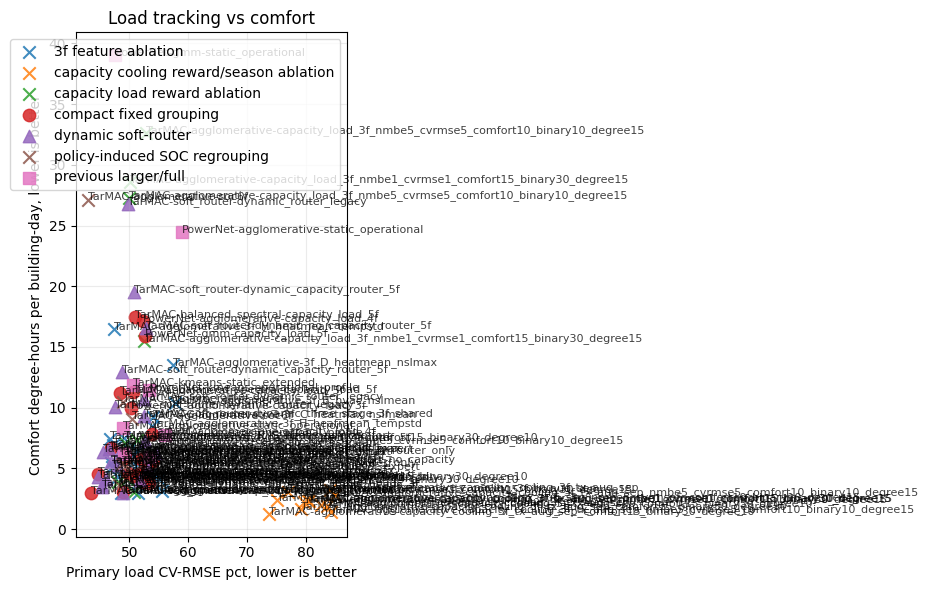

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
marker_map = {
    "compact fixed grouping": "o",
    "previous larger/full": "s",
    "dynamic soft-router": "^",
}

for feature_group, group_df in df.groupby("feature_group"):
    marker = marker_map.get(feature_group, "x")
    ax.scatter(
        group_df["primary_load_cv_rmse_pct"],
        group_df["primary_comfort_degree_hours_per_building_day"],
        label=feature_group,
        marker=marker,
        s=80,
        alpha=0.85,
    )

for _, row in df.iterrows():
    arch = str(row.get("architecture", "exp")).split()[0]
    method = row.get("grouping_method_short", "")
    features = row.get("grouping_feature_set_short", "")
    label = f"{arch}-{method}-{features}"
    ax.annotate(
        label,
        (row["primary_load_cv_rmse_pct"], row["primary_comfort_degree_hours_per_building_day"]),
        fontsize=8,
        alpha=0.75,
    )

ax.set_xlabel("Primary load CV-RMSE pct, lower is better")
ax.set_ylabel("Comfort degree-hours per building-day, lower is better")
ax.set_title("Load tracking vs comfort")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()